In [1]:
!pip install optuna imblearn shap pycox lifelines torchtuples xgboost



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import random, os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    mean_absolute_error, mean_squared_error, r2_score
)

from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE

import optuna
from xgboost import XGBClassifier

# Survival Analysis
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.utils import concordance_index

# SHAP
import shap

In [3]:
# pip install xgboost==2.0.3


In [4]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

In [5]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df = df.drop(['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'], axis=1)

# Label Encoding
le = LabelEncoder()
for col in df.select_dtypes('object').columns:
    df[col] = le.fit_transform(df[col])

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

print("\nOriginal Class Distribution:")
print(y.value_counts())
print("\nUsing SMOTE + Tomek Links Oversampling...")
oversampler = SMOTETomek(
    smote=SMOTE(random_state=SEED),
    random_state=SEED
)
X_resampled, y_resampled = oversampler.fit_resample(X, y)

print("\nAfter SMOTE + Tomek Links:")
print(y_resampled.value_counts())


Original Class Distribution:
Attrition
0    1233
1     237
Name: count, dtype: int64

Using SMOTE + Tomek Links Oversampling...

After SMOTE + Tomek Links:
Attrition
1    1189
0    1189
Name: count, dtype: int64


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y_resampled, test_size=0.3, random_state=SEED
)


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "SVM": SVC(kernel='linear', probability=True),
    # "SVM (RBF)": SVC(kernel='rbf', probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "KNN": KNeighborsClassifier(),
    # "XGBoost": XGBClassifier(
    #     n_estimators=200, learning_rate=0.05, max_depth=5,
    #     subsample=0.8, colsample_bytree=0.8, random_state=42
    # )
}

results = []
reports = {}

def calculate_errors(y_true, y_pred, y_prob):
    mae = mean_absolute_error(y_true, y_prob)
    mse = mean_squared_error(y_true, y_prob)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_prob)

    return mae, mse, rmse, r2


In [8]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    mae, mse, rmse, r2 = calculate_errors(y_test.values, y_pred, y_prob)

    results.append([name, acc, auc, mae, mse, rmse, r2])
    reports[name] = classification_report(y_test, y_pred)

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "ROC-AUC", "MAE", "MSE", "RMSE", "R2"])
print("\n================ BASELINE MODEL RESULTS ================")
print(results_df)


================ BASELINE MODEL RESULTS ================
                 Model  Accuracy   ROC-AUC       MAE       MSE      RMSE  \
0  Logistic Regression  0.850140  0.943310  0.198830  0.092613  0.304323   
1                  SVM  0.872549  0.945979  0.190517  0.088924  0.298202   
2        Random Forest  0.901961  0.969921  0.236246  0.084994  0.291537   
3                  KNN  0.809524  0.948400  0.220168  0.129076  0.359271   

         R2  
0  0.629445  
1  0.644202  
2  0.659928  
3  0.483552  


In [9]:
for name in reports:
    print("\n====================", name, "====================")
    print(reports[name])


==================== Logistic Regression ====================
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       363
           1       0.85      0.85      0.85       351

    accuracy                           0.85       714
   macro avg       0.85      0.85      0.85       714
weighted avg       0.85      0.85      0.85       714


==================== SVM ====================
              precision    recall  f1-score   support

           0       0.85      0.90      0.88       363
           1       0.89      0.84      0.87       351

    accuracy                           0.87       714
   macro avg       0.87      0.87      0.87       714
weighted avg       0.87      0.87      0.87       714


==================== Random Forest ====================
              precision    recall  f1-score   support

           0       0.89      0.92      0.90       363
           1       0.91      0.89      0.90       351

    accuracy   

In [10]:
baseline_xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    eval_metric="logloss"
)

baseline_xgb.fit(X_train, y_train)
baseline_pred = baseline_xgb.predict(X_test)
baseline_prob = baseline_xgb.predict_proba(X_test)[:, 1]

baseline_acc = accuracy_score(y_test, baseline_pred)
baseline_auc = roc_auc_score(y_test, baseline_prob)

mae, mse, rmse, r2= calculate_errors(y_test.values, baseline_pred, baseline_prob)
print("\n================ BASELINE XGBOOST =================")
print(f"Accuracy: {baseline_acc:.5f}")
print(f"ROC-AUC : {baseline_auc:.5f}")
print(f"MAE:  {mae:.5f}")
print(f"MSE:  {mse:.5f}")
print(f"RMSE: {rmse:.5f}")
print(f"R²:   {r2:.5f}")
print("\nClassification Report:\n", classification_report(y_test, baseline_pred))



================ BASELINE XGBOOST =================
Accuracy: 0.91597
ROC-AUC : 0.96923
MAE:  0.15349
MSE:  0.06595
RMSE: 0.25680
R²:   0.73614

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.92      0.92       363
           1       0.92      0.91      0.91       351

    accuracy                           0.92       714
   macro avg       0.92      0.92      0.92       714
weighted avg       0.92      0.92      0.92       714



In [11]:
# OPTUNA XGBOOST
# ============================
from sklearn.model_selection import StratifiedKFold

def optimize_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
        "random_state": SEED,
        "seed": SEED,
        "eval_metric": "logloss",
        "tree_method": "hist",
    }

    # use ONLY the training set for cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    auc_scores = []

    for train_idx, valid_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[valid_idx]

        model = XGBClassifier(**params)
        model.fit(X_tr, y_tr)
        prob = model.predict_proba(X_val)[:, 1]

        auc = roc_auc_score(y_val, prob)
        auc_scores.append(auc)

    return np.mean(auc_scores)



study = optuna.create_study(direction="maximize")
study.optimize(optimize_xgb, n_trials=100)

best_params = study.best_params
best_params.update({
    "random_state": SEED,
    "seed": SEED,
    "eval_metric": "logloss",
    "tree_method": "hist"
})

optuna_xgb = XGBClassifier(**best_params)
optuna_xgb.fit(X_train, y_train)

opt_pred = optuna_xgb.predict(X_test)
opt_prob = optuna_xgb.predict_proba(X_test)[:, 1]

opt_acc = accuracy_score(y_test, opt_pred)
opt_auc = roc_auc_score(y_test, opt_prob)

mae, mse, rmse, r2= calculate_errors(y_test.values, opt_pred, opt_prob)

[I 2026-04-29 14:07:30,423] A new study created in memory with name: no-name-3a36cfaf-8b20-43a8-ae61-6fd2a96b0a8d
[I 2026-04-29 14:07:30,950] Trial 0 finished with value: 0.9459267768119943 and parameters: {'n_estimators': 584, 'max_depth': 4, 'learning_rate': 0.26031593286751925, 'subsample': 0.5542226359111553, 'colsample_bytree': 0.7064670200227958, 'gamma': 1.7243671062568517, 'min_child_weight': 9, 'reg_alpha': 2.3828936168911885, 'reg_lambda': 0.015272892053811993}. Best is trial 0 with value: 0.9459267768119943.
[I 2026-04-29 14:07:31,190] Trial 1 finished with value: 0.9455731383943634 and parameters: {'n_estimators': 216, 'max_depth': 4, 'learning_rate': 0.25350150165671737, 'subsample': 0.7719914329890118, 'colsample_bytree': 0.7637685368599084, 'gamma': 2.3446667110981236, 'min_child_weight': 3, 'reg_alpha': 2.9372151260146935, 'reg_lambda': 2.4123485358840795}. Best is trial 0 with value: 0.9459267768119943.
[I 2026-04-29 14:07:31,723] Trial 2 finished with value: 0.9586316

In [12]:
print("\n================ OPTUNA-TUNED XGBOOST ================")
print(f"Accuracy: {opt_acc:.5f}")
print(f"ROC-AUC : {opt_auc:.5f}")
print(f"MAE:  {mae:.5f}")
print(f"MSE:  {mse:.5f}")
print(f"RMSE: {rmse:.5f}")
print(f"R²:   {r2:.5f}")
print("\nClassification Report:\n", classification_report(y_test, opt_pred))



================ OPTUNA-TUNED XGBOOST ================
Accuracy: 0.92437
ROC-AUC : 0.97604
MAE:  0.10278
MSE:  0.05502
RMSE: 0.23457
R²:   0.77984

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.94      0.93       363
           1       0.94      0.90      0.92       351

    accuracy                           0.92       714
   macro avg       0.93      0.92      0.92       714
weighted avg       0.92      0.92      0.92       714



In [13]:
comp_df = pd.DataFrame({
    "Model": ["Baseline XGBoost", "Optuna XGBoost"],
    "Accuracy": [baseline_acc, opt_acc],
    "ROC-AUC": [baseline_auc, opt_auc]
})

print("\n==================== COMPARISON ====================")
print(comp_df)


==================== COMPARISON ====================
              Model  Accuracy   ROC-AUC
0  Baseline XGBoost  0.915966  0.969226
1    Optuna XGBoost  0.924370  0.976039


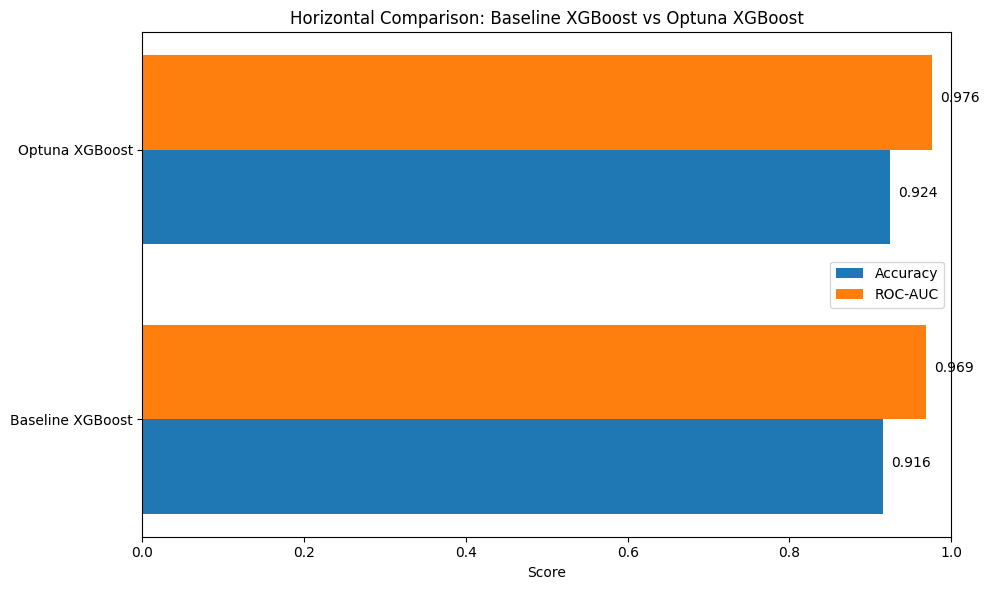

In [14]:
plt.figure(figsize=(10, 6))

models = ["Baseline XGBoost", "Optuna XGBoost"]
accuracy_scores = [baseline_acc, opt_acc]
auc_scores = [baseline_auc, opt_auc]

# Combine metrics in one array for horizontal bars
scores = [accuracy_scores, auc_scores]
labels = ["Accuracy", "ROC-AUC"]

# Plot horizontal bars
bar_height = 0.35
y = np.arange(len(models))

plt.barh(y - bar_height/2, accuracy_scores, height=bar_height, label="Accuracy")
plt.barh(y + bar_height/2, auc_scores, height=bar_height, label="ROC-AUC")

plt.xlabel("Score")
plt.title("Horizontal Comparison: Baseline XGBoost vs Optuna XGBoost")
plt.xlim(0, 1)
plt.yticks(y, models)

# Add value labels
for i, v in enumerate(accuracy_scores):
    plt.text(v + 0.01, i - bar_height/2, f"{v:.3f}")

for i, v in enumerate(auc_scores):
    plt.text(v + 0.01, i + bar_height/2, f"{v:.3f}")

plt.legend()
plt.tight_layout()
plt.show()

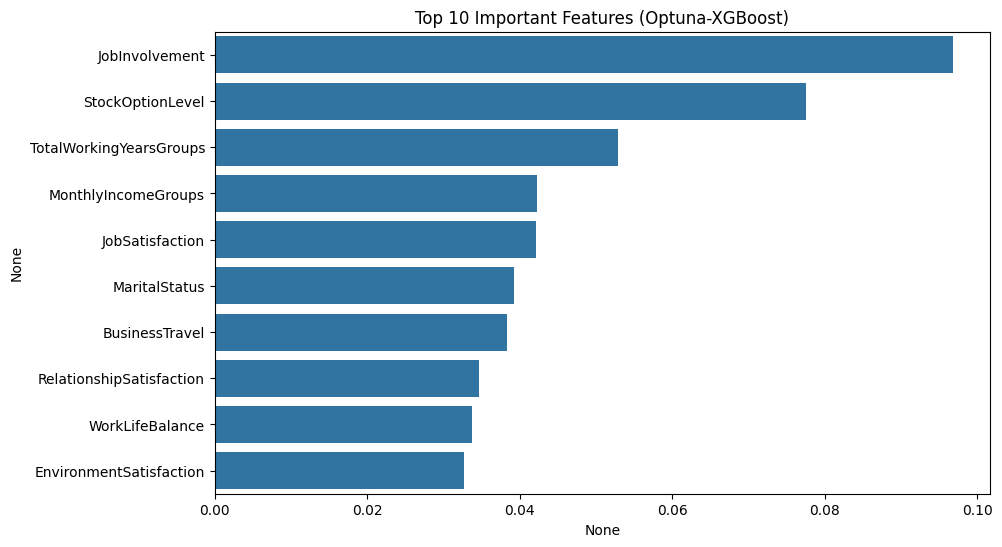

In [15]:
importance = pd.Series(optuna_xgb.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importance.head(10), y=importance.head(10).index)
plt.title("Top 10 Important Features (Optuna-XGBoost)")
plt.show()

In [16]:
survival_df = df.copy()

survival_df["event"] = survival_df["Attrition"]
survival_df["time"] = survival_df["YearsAtCompany"]

# remove target/time from predictors
X_surv = pd.get_dummies(
    survival_df.drop(columns=["Attrition", "time", "event"]),
    drop_first=True
)

# remove zero-variance columns
X_surv = X_surv.loc[:, X_surv.std() > 0]

# remove duplicates
X_surv = X_surv.loc[:, ~X_surv.columns.duplicated()]

# remove highly correlated (>0.95)
corr = X_surv.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
X_surv = X_surv.drop(columns=to_drop, errors="ignore")

final_df = pd.concat([X_surv, survival_df[["time", "event"]]], axis=1)


In [17]:
cph = CoxPHFitter(penalizer=0.1)
cph.fit(final_df, duration_col="time", event_col="event")

print("\n=================== COX SURVIVAL SUMMARY ===================")
cph.print_summary()


=================== COX SURVIVAL SUMMARY ===================


<lifelines.CoxPHFitter: fitted with 1470 total observations, 1233 right-censored observations>
             duration col = 'time'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 1470
number of events observed = 237
   partial log-likelihood = -1315.66
         time fit was run = 2026-04-29 08:38:49 UTC

---
                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                 
Unnamed: 0               -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Age                      -0.01      0.99      0.01           -0.03            0.00                0.97                1.00
BusinessTravel           -0.00      1.00      0.08           -0.15            0.15                0.86                1.16
DailyRate                -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Department                0.24      1.27      0.11            0.03            0.46                1.03                1.58
DistanceFromHome          0.01      1.01      0.01            0.00            0.03                1.00                1.03
Education                -0.04      0.96      0.04           -0.12            0.04                0.89                1.04
EducationField            0.01      1.01      0.04           -0.06            0.09                0.94                1.09
EnvironmentSatisfaction  -0.14      0.87      0.05           -0.23           -0.05                0.79                0.95
Gender                    0.13      1.13      0.11           -0.08            0.33                0.92                1.40
HourlyRate               -0.00      1.00      0.00           -0.01            0.00                0.99                1.00
JobInvolvement           -0.23      0.79      0.07           -0.37           -0.09                0.69                0.91
JobLevel                 -0.19      0.82      0.05           -0.28           -0.10                0.75                0.90
JobRole                   0.01      1.01      0.02           -0.04            0.05                0.96                1.05
JobSatisfaction          -0.16      0.85      0.05           -0.25           -0.07                0.78                0.93
MaritalStatus             0.24      1.27      0.08            0.09            0.40                1.09                1.49
MonthlyIncome            -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
MonthlyRate               0.00      1.00      0.00           -0.00            0.00                1.00                1.00
NumCompaniesWorked        0.09      1.09      0.02            0.05            0.13                1.05                1.14
OverTime                  0.79      2.21      0.11            0.58            1.00                1.79                2.73
PercentSalaryHike        -0.00      1.00      0.02           -0.03            0.03                0.97                1.03
PerformanceRating         0.03      1.03      0.16           -0.29            0.34                0.75                1.41
RelationshipSatisfaction -0.07      0.93      0.05           -0.16            0.02                0.85                1.02
StockOptionLevel         -0.15      0.86      0.07           -0.29           -0.02                0.75                0.98
TotalWorkingYears        -0.04      0.96      0.01           -0.06           -0.02                0.95                0.98
TrainingTimesLastYear    -0.06      0.94      0.04           -0.14            0.02                0.87                1.02
WorkLifeBalance          -0.11      0.90      0.07           -0.25            0.03                0.78                1.03
YearsAtC

In [18]:
c_index = concordance_index(
    final_df["time"],
    -cph.predict_partial_hazard(final_df),
    final_df["event"]
)

print(f"\nConcordance Index (Cox): {c_index:.4f}")


Concordance Index (Cox): 0.9476


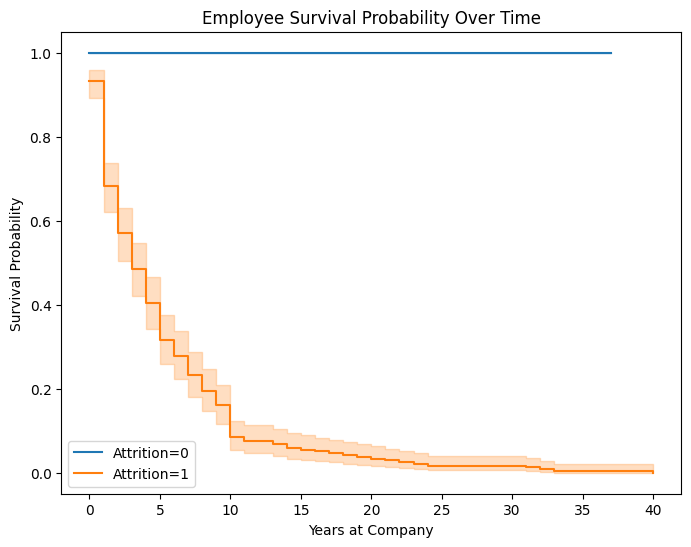

In [19]:
# Kaplan-Meier Curves
kmf = KaplanMeierFitter()
plt.figure(figsize=(8, 6))

for label, grp in final_df.groupby("event"):
    kmf.fit(grp["time"], grp["event"], label=f"Attrition={label}")
    kmf.plot_survival_function()

plt.title("Employee Survival Probability Over Time")
plt.xlabel("Years at Company")
plt.ylabel("Survival Probability")
plt.show()

/tmp/ipykernel_8642/588993888.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


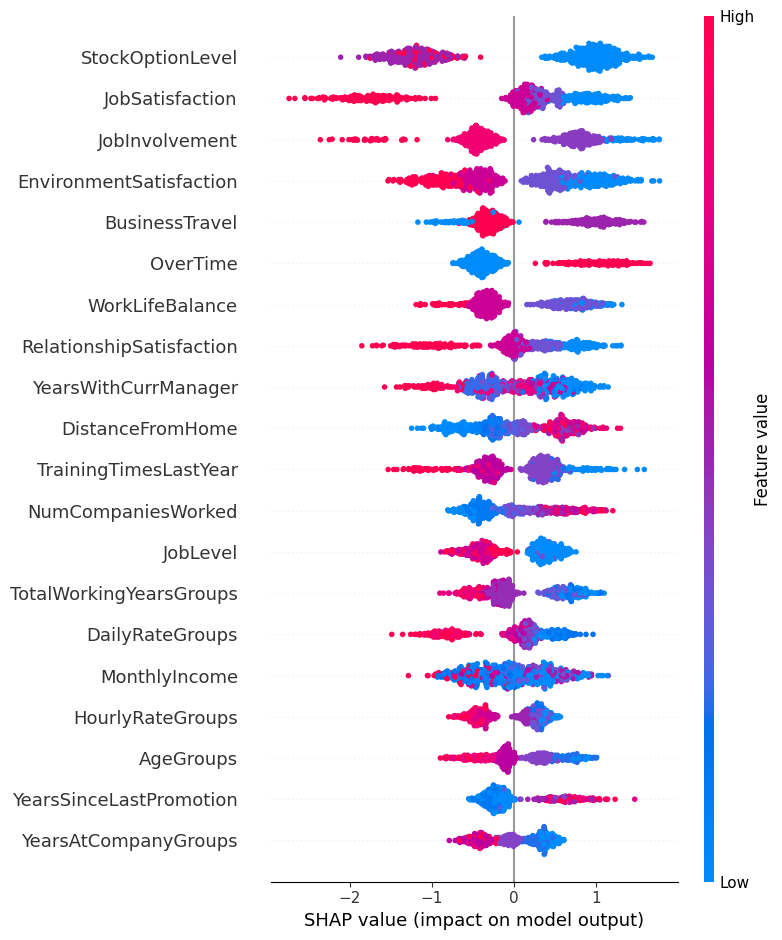

/tmp/ipykernel_8642/588993888.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar")


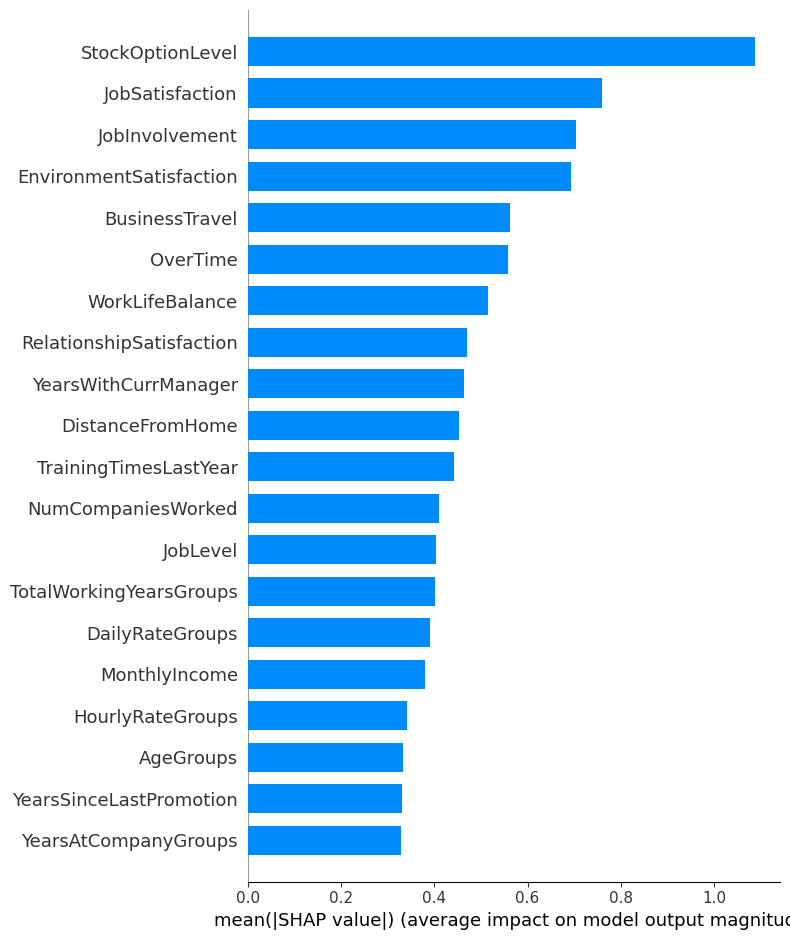

In [20]:

explainer = shap.Explainer(optuna_xgb)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")

/tmp/ipykernel_8642/3679490302.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=all_acc_df, x="Accuracy", y="Model", palette="coolwarm")


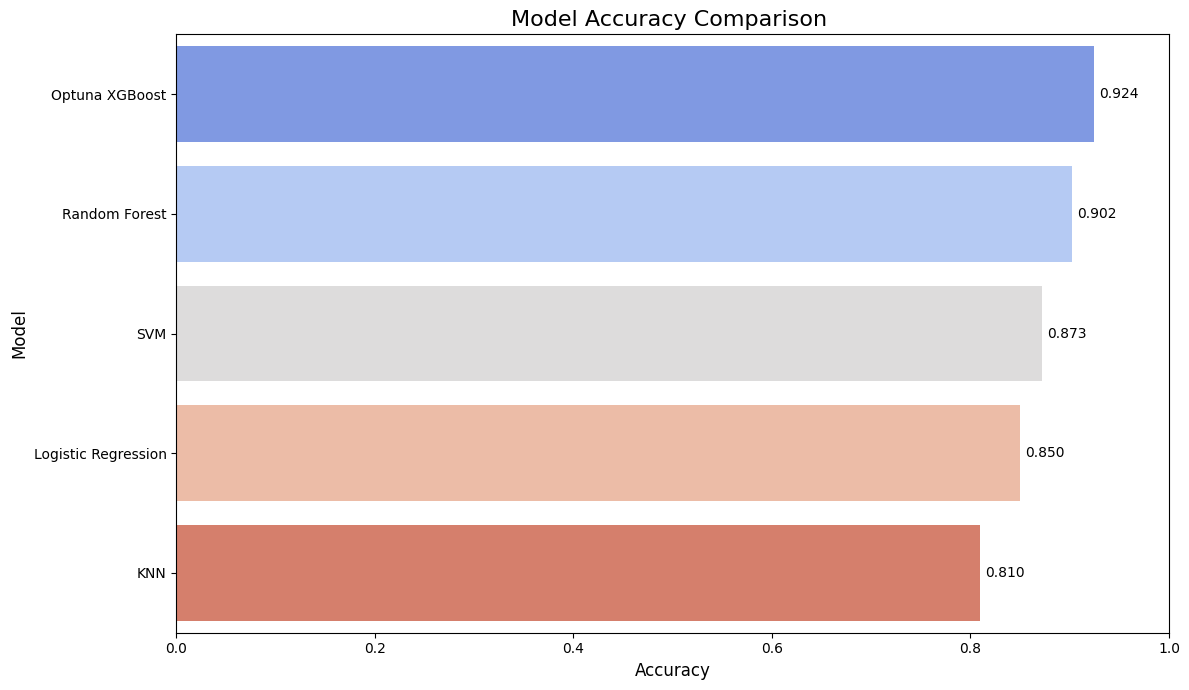

In [21]:
# =====================================================
#   ACCURACY COMPARISON OF ALL MODELS IN ONE PLOT
# =====================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Add Baseline XGB and Optuna XGB to your DataFrame
all_acc_df = results_df[["Model", "Accuracy"]].copy()

# Append the XGBoost models
all_acc_df = pd.concat([
    all_acc_df,
    pd.DataFrame({
        "Model": [ "Optuna XGBoost"],
        "Accuracy": [ opt_acc]
    })
], ignore_index=True)

# Sort for clean visualization
all_acc_df = all_acc_df.sort_values(by="Accuracy", ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(data=all_acc_df, x="Accuracy", y="Model", palette="coolwarm")

plt.title("Model Accuracy Comparison ", fontsize=16)
plt.xlabel("Accuracy", fontsize=12)
plt.ylabel("Model", fontsize=12)

# Add score labels
for index, value in enumerate(all_acc_df["Accuracy"]):
    plt.text(value + 0.005, index, f"{value:.3f}", va='center')

plt.xlim(0, 1)   # accuracy range
plt.tight_layout()
plt.show()
